In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
ROOT = Path.cwd().parent

FEATURE_FILE = ROOT / "features/test_cohort_10_features.tsv"

print(ROOT)
print(FEATURE_FILE)

/home/ubuntu/py-ctdna
/home/ubuntu/py-ctdna/features/test_cohort_10_features.tsv


In [5]:
df = pd.read_csv(
    FEATURE_FILE,
    sep="\t"
)

df

,run_id,sample_id,ml_label,ELSA_0001,ELSA_0002,ELSA_0003,ELSA_0004,ELSA_0005,ELSA_0006,ELSA_0007,...,ELSA_2464,ELSA_2465,ELSA_2466,ELSA_2467,ELSA_2468,ELSA_2469,ELSA_2470,ELSA_2471,ELSA_2472,ELSA_2473
0,SRR15143359,BMD01123,0,0.131868,0.132964,0.024316,0.099476,0.036792,0.025404,0.087019,...,0.033333,0.029636,0.068871,0.087983,0.044534,0.030303,0.029126,0.246154,0.147887,0.075472
1,SRR15143291,BMD01062,0,0.082822,0.122137,0.031809,0.061321,0.049650,0.021875,0.081761,...,0.045289,0.034200,0.039486,0.058966,0.101284,0.036768,0.100809,0.152659,0.111111,0.040506
2,SRR9982411,BMD00623,1,0.097234,0.120722,0.029621,0.059701,0.043869,0.031234,0.095282,...,0.044858,0.032809,0.041643,0.050752,0.110360,0.046154,0.076669,0.128655,0.144928,0.069357
3,SRR9982564,BMD00840,0,0.095533,0.110018,0.019346,0.093633,0.039216,0.022645,0.088106,...,0.026421,0.027133,0.039720,0.038912,0.095207,0.038260,0.060872,0.126214,0.124792,0.061463
4,SRR9982549,BMD00404,1,0.097673,0.097809,0.011614,0.022863,0.024442,0.011818,0.040570,...,0.021066,0.014124,0.018450,0.032822,0.041416,0.034755,0.032434,0.093581,0.077701,0.030066
5,SRR9982526,BMD00122,0,0.157647,0.114478,0.020878,0.062374,0.038026,0.013158,0.068820,...,0.031298,0.039700,0.039379,0.046736,0.100699,0.043442,0.069121,0.121703,0.104381,0.061867
6,SRR9982384,BMD00186,1,0.034521,0.078228,0.027897,0.035511,0.045977,0.022631,0.071429,...,0.038618,0.025172,0.075893,0.067400,0.076566,0.046791,0.065997,0.120427,0.129496,0.060897
7,SRR9982899,BMD00326,1,0.147314,0.166468,0.030608,0.071795,0.041237,0.021576,0.057111,...,0.034972,0.037267,0.039553,0.024088,0.097202,0.052599,0.056011,0.130542,0.109890,0.046122
8,SRR9982493,BMD00494,0,0.128635,0.142336,0.022911,0.081197,0.038345,0.020802,0.080039,...,0.042028,0.029051,0.041292,0.034237,0.092283,0.039151,0.079266,0.142627,0.084586,0.062581


In [6]:
df["ml_label"].value_counts()

ml_label
0    5
1    4
Name: count, dtype: int64

In [7]:
feature_cols = [
    c for c in df.columns
    if c.startswith("ELSA_")
]

X = df[feature_cols]
y = df["ml_label"]

print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("Controls:", (y == 0).sum())
print("Stage I cancer:", (y == 1).sum())

Samples: 9
Features: 2473
Controls: 5
Stage I cancer: 4


In [8]:
missing_per_sample = X.isna().sum(axis=1)

pd.DataFrame({
    "sample_id": df["sample_id"],
    "label": y,
    "missing_features": missing_per_sample,
    "missing_percent": missing_per_sample / X.shape[1] * 100
})

,sample_id,label,missing_features,missing_percent
0,BMD01123,0,16,0.646987
1,BMD01062,0,16,0.646987
2,BMD00623,1,16,0.646987
3,BMD00840,0,16,0.646987
4,BMD00404,1,16,0.646987
5,BMD00122,0,16,0.646987
6,BMD00186,1,16,0.646987
7,BMD00326,1,17,0.687424
8,BMD00494,0,16,0.646987


In [9]:
X.isna().sum().sum() / X.size * 100

np.float64(0.6514804331221639)

In [10]:
overall_missing = X.isna().sum().sum()
total_values = X.size
overall_missing_pct = overall_missing / total_values * 100

print(f"Missing values: {overall_missing:,}/{total_values:,}")
print(f"Overall missingness: {overall_missing_pct:.3f}%")
print(f"Observed values: {100 - overall_missing_pct:.3f}%")

Missing values: 145/22,257
Overall missingness: 0.651%
Observed values: 99.349%


In [11]:
sample_qc = pd.DataFrame({
    "run_id": df["run_id"],
    "sample_id": df["sample_id"],
    "label": y.map({0: "Control", 1: "Stage I cancer"}),
    "observed_features": X.notna().sum(axis=1),
    "missing_features": X.isna().sum(axis=1),
    "missing_percent": X.isna().mean(axis=1) * 100,
})

sample_qc.sort_values("missing_percent", ascending=False)


,run_id,sample_id,label,observed_features,missing_features,missing_percent
7,SRR9982899,BMD00326,Stage I cancer,2456,17,0.687424
0,SRR15143359,BMD01123,Control,2457,16,0.646987
1,SRR15143291,BMD01062,Control,2457,16,0.646987
3,SRR9982564,BMD00840,Control,2457,16,0.646987
2,SRR9982411,BMD00623,Stage I cancer,2457,16,0.646987
4,SRR9982549,BMD00404,Stage I cancer,2457,16,0.646987
5,SRR9982526,BMD00122,Control,2457,16,0.646987
6,SRR9982384,BMD00186,Stage I cancer,2457,16,0.646987
8,SRR9982493,BMD00494,Control,2457,16,0.646987


In [13]:
region_qc = pd.DataFrame({
    "region_id": feature_cols,
    "observed_samples": X.notna().sum(axis=0).values,
    "missing_samples": X.isna().sum(axis=0).values,
    "missing_percent": (X.isna().mean(axis=0) * 100).values,
})

print("Regions missing in all samples:",
      (region_qc["observed_samples"] == 0).sum())

region_qc.sort_values(
    ["missing_percent", "region_id"],
    ascending=[False, True]
).head(25)


Regions missing in all samples: 16


,region_id,observed_samples,missing_samples,missing_percent
941,ELSA_0942,0,9,100.000000
942,ELSA_0943,0,9,100.000000
943,ELSA_0944,0,9,100.000000
944,ELSA_0945,0,9,100.000000
945,ELSA_0946,0,9,100.000000
946,ELSA_0947,0,9,100.000000
947,ELSA_0948,0,9,100.000000
948,ELSA_0949,0,9,100.000000
949,ELSA_0950,0,9,100.000000
950,ELSA_0951,0,9,100.000000


In [14]:
sample_methylation = sample_qc.copy()
sample_methylation["mean_methylation"] = X.mean(axis=1, skipna=True)
sample_methylation["median_methylation"] = X.median(axis=1, skipna=True)

sample_methylation[
    ["run_id", "sample_id", "label", "mean_methylation", "median_methylation"]
].sort_values("mean_methylation")


,run_id,sample_id,label,mean_methylation,median_methylation
4,SRR9982549,BMD00404,Stage I cancer,0.060751,0.036016
5,SRR9982526,BMD00122,Control,0.075325,0.051227
3,SRR9982564,BMD00840,Control,0.076027,0.050963
0,SRR15143359,BMD01123,Control,0.078395,0.054015
8,SRR9982493,BMD00494,Control,0.078634,0.053528
7,SRR9982899,BMD00326,Stage I cancer,0.079913,0.053737
6,SRR9982384,BMD00186,Stage I cancer,0.084634,0.060224
1,SRR15143291,BMD01062,Control,0.084873,0.060185
2,SRR9982411,BMD00623,Stage I cancer,0.087781,0.063830


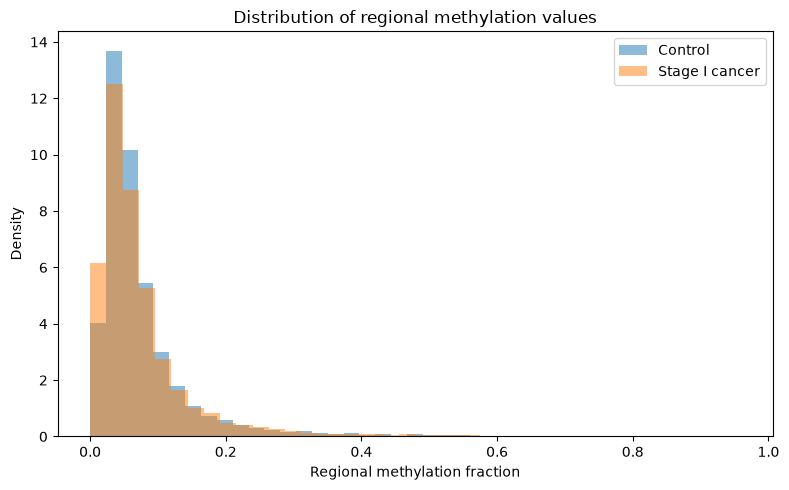

In [15]:
control_values = X.loc[y == 0].to_numpy().ravel()
cancer_values = X.loc[y == 1].to_numpy().ravel()

control_values = control_values[~np.isnan(control_values)]
cancer_values = cancer_values[~np.isnan(cancer_values)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(control_values, bins=40, density=True, alpha=0.5, label="Control")
ax.hist(cancer_values, bins=40, density=True, alpha=0.5, label="Stage I cancer")
ax.set_xlabel("Regional methylation fraction")
ax.set_ylabel("Density")
ax.set_title("Distribution of regional methylation values")
ax.legend()
plt.tight_layout()
plt.show()


In [16]:
region_stats = []

for region in feature_cols:
    ctrl = X.loc[y == 0, region].dropna()
    ca = X.loc[y == 1, region].dropna()

    ctrl_mean = ctrl.mean() if len(ctrl) else np.nan
    ca_mean = ca.mean() if len(ca) else np.nan

    delta = (
        ca_mean - ctrl_mean
        if pd.notna(ctrl_mean) and pd.notna(ca_mean)
        else np.nan
    )

    region_stats.append({
        "region_id": region,
        "control_n": len(ctrl),
        "cancer_n": len(ca),
        "control_mean": ctrl_mean,
        "cancer_mean": ca_mean,
        "delta_methylation": delta,
        "abs_delta": abs(delta) if pd.notna(delta) else np.nan,
    })

region_stats = pd.DataFrame(region_stats)
comparable = region_stats.dropna(
    subset=["control_mean", "cancer_mean"]
).copy()

print("Comparable regions:", len(comparable))
print("Higher methylation in cancer:",
      (comparable["delta_methylation"] > 0).sum())
print("Lower methylation in cancer:",
      (comparable["delta_methylation"] < 0).sum())

comparable.sort_values("abs_delta", ascending=False).head(20)


Comparable regions: 2457
Higher methylation in cancer: 1149
Lower methylation in cancer: 1308


,region_id,control_n,cancer_n,control_mean,cancer_mean,delta_methylation,abs_delta
2156,ELSA_2157,5,4,0.127372,0.330973,0.203602,0.203602
776,ELSA_0777,5,4,0.421828,0.268516,-0.153311,0.153311
274,ELSA_0275,5,4,0.210934,0.073587,-0.137347,0.137347
1076,ELSA_1077,5,4,0.214183,0.349403,0.135221,0.135221
2332,ELSA_2333,5,4,0.070406,0.202838,0.132432,0.132432
523,ELSA_0524,5,4,0.232704,0.100864,-0.131840,0.131840
524,ELSA_0525,5,4,0.232704,0.100864,-0.131840,0.131840
2374,ELSA_2375,5,4,0.078980,0.208843,0.129862,0.129862
1425,ELSA_1426,5,4,0.179237,0.307594,0.128357,0.128357
2381,ELSA_2382,5,4,0.353795,0.469935,0.116140,0.116140


In [17]:
top_regions = (
    comparable
    .sort_values("abs_delta", ascending=False)
    .head(20)
    .copy()
)

top_regions


,region_id,control_n,cancer_n,control_mean,cancer_mean,delta_methylation,abs_delta
2156,ELSA_2157,5,4,0.127372,0.330973,0.203602,0.203602
776,ELSA_0777,5,4,0.421828,0.268516,-0.153311,0.153311
274,ELSA_0275,5,4,0.210934,0.073587,-0.137347,0.137347
1076,ELSA_1077,5,4,0.214183,0.349403,0.135221,0.135221
2332,ELSA_2333,5,4,0.070406,0.202838,0.132432,0.132432
523,ELSA_0524,5,4,0.232704,0.100864,-0.131840,0.131840
524,ELSA_0525,5,4,0.232704,0.100864,-0.131840,0.131840
2374,ELSA_2375,5,4,0.078980,0.208843,0.129862,0.129862
1425,ELSA_1426,5,4,0.179237,0.307594,0.128357,0.128357
2381,ELSA_2382,5,4,0.353795,0.469935,0.116140,0.116140


In [22]:
from statsmodels.stats.multitest import multipletests

test_rows = []

for region in feature_cols:
    ctrl = X.loc[y == 0, region].dropna()
    ca = X.loc[y == 1, region].dropna()

    if len(ctrl) >= 2 and len(ca) >= 2:
        stat, p = stats.mannwhitneyu(
            ca,
            ctrl,
            alternative="two-sided"
        )
    else:
        stat, p = np.nan, np.nan

    test_rows.append({
        "region_id": region,
        "U_statistic": stat,
        "p_value": p
    })

tests = pd.DataFrame(test_rows)

valid = tests["p_value"].notna()
tests.loc[valid, "fdr_bh"] = multipletests(
    tests.loc[valid, "p_value"],
    method="fdr_bh"
)[1]

region_analysis = comparable.merge(
    tests,
    on="region_id",
    how="left"
)

region_analysis.sort_values(
    ["p_value", "abs_delta"],
    ascending=[True, False]
).head(20)


,region_id,control_n,cancer_n,control_mean,cancer_mean,delta_methylation,abs_delta,U_statistic,p_value,fdr_bh
2365,ELSA_2382,5,4,0.353795,0.469935,0.116140,0.116140,20.0,0.015873,1.0
227,ELSA_0228,5,4,0.449543,0.336468,-0.113075,0.113075,0.0,0.015873,1.0
57,ELSA_0058,5,4,0.058108,0.156135,0.098027,0.098027,20.0,0.015873,1.0
1907,ELSA_1924,5,4,0.115622,0.047380,-0.068243,0.068243,0.0,0.015873,1.0
77,ELSA_0078,5,4,0.313885,0.247584,-0.066301,0.066301,0.0,0.015873,1.0
1462,ELSA_1479,5,4,0.251319,0.315577,0.064258,0.064258,20.0,0.015873,1.0
2103,ELSA_2120,5,4,0.030296,0.085127,0.054831,0.054831,20.0,0.015873,1.0
225,ELSA_0226,5,4,0.071916,0.024522,-0.047394,0.047394,0.0,0.015873,1.0
629,ELSA_0630,5,4,0.036322,0.077200,0.040879,0.040879,20.0,0.015873,1.0
457,ELSA_0458,5,4,0.076722,0.041698,-0.035025,0.035025,0.0,0.015873,1.0


In [19]:
usable_features = [
    c for c in feature_cols
    if X[c].notna().any()
]

X_pca = X[usable_features].copy()

# Median imputation for visualization only
X_pca = X_pca.fillna(X_pca.median(axis=0))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "sample_id": df["sample_id"],
    "label": y.map({0: "Control", 1: "Stage I cancer"})
})

print(
    "Explained variance:",
    np.round(pca.explained_variance_ratio_ * 100, 2),
    "%"
)

pca_df


Explained variance: [29.56 16.22] %


,PC1,PC2,sample_id,label
0,0.943956,-52.604619,BMD01123,Control
1,22.873573,7.630564,BMD01062,Control
2,33.841184,0.959145,BMD00623,Stage I cancer
3,-10.017330,-0.761029,BMD00840,Control
4,-64.396278,11.432538,BMD00404,Stage I cancer
5,-7.897755,1.231854,BMD00122,Control
6,23.609730,24.404752,BMD00186,Stage I cancer
7,0.206651,2.631220,BMD00326,Stage I cancer
8,0.836269,5.075575,BMD00494,Control


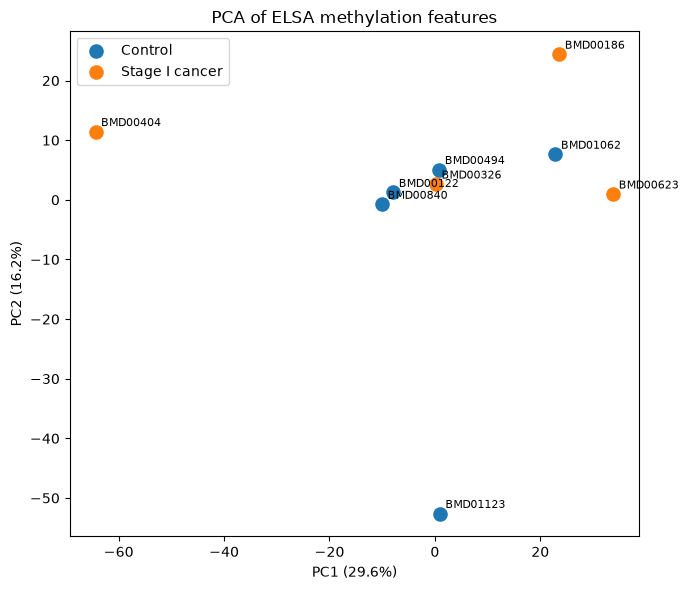

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))

for label in ["Control", "Stage I cancer"]:
    tmp = pca_df[pca_df["label"] == label]
    ax.scatter(
        tmp["PC1"],
        tmp["PC2"],
        label=label,
        s=90
    )

    for _, row in tmp.iterrows():
        ax.annotate(
            row["sample_id"],
            (row["PC1"], row["PC2"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)"
)
ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)"
)
ax.set_title("PCA of ELSA methylation features")
ax.legend()
plt.tight_layout()
plt.show()


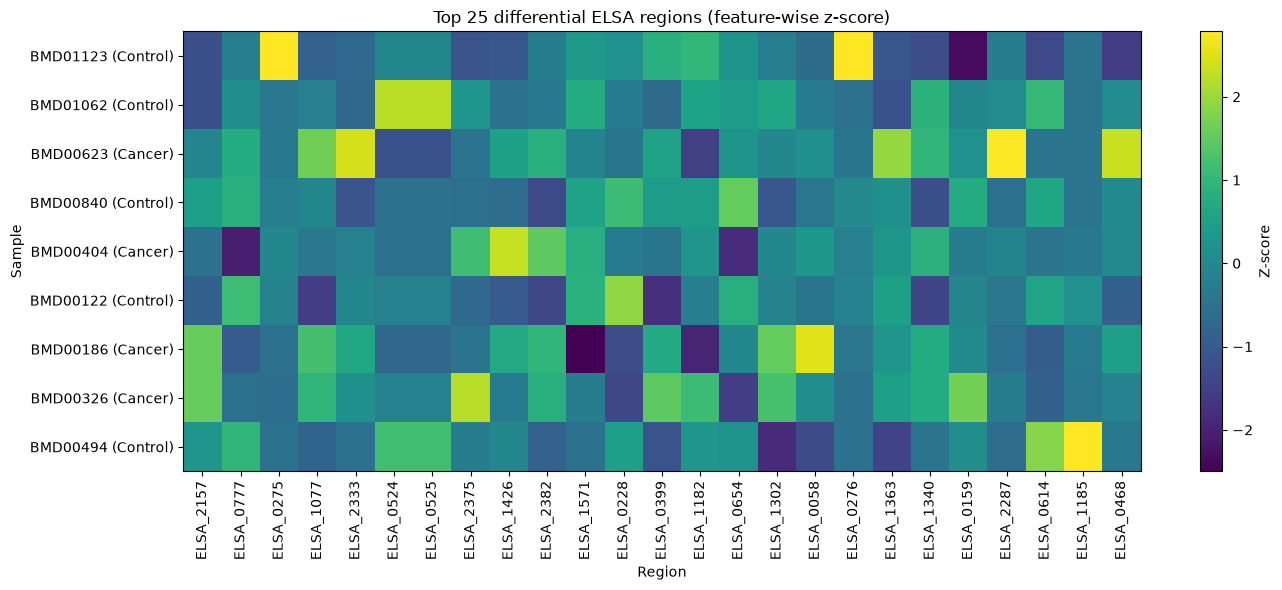

In [21]:
top25 = (
    comparable
    .sort_values("abs_delta", ascending=False)
    .head(25)["region_id"]
    .tolist()
)

heat = X[top25].copy()
heat = heat.fillna(heat.median(axis=0))

# Z-score each region to make relative differences easier to see
heat_z = (heat - heat.mean(axis=0)) / heat.std(axis=0, ddof=0)
heat_z = heat_z.replace([np.inf, -np.inf], np.nan).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heat_z.to_numpy(), aspect="auto")

ax.set_yticks(range(len(df)))
ax.set_yticklabels(
    [
        f"{sid} ({'Cancer' if lab == 1 else 'Control'})"
        for sid, lab in zip(df["sample_id"], y)
    ]
)

ax.set_xticks(range(len(top25)))
ax.set_xticklabels(top25, rotation=90)

ax.set_title("Top 25 differential ELSA regions (feature-wise z-score)")
ax.set_xlabel("Region")
ax.set_ylabel("Sample")

fig.colorbar(im, ax=ax, label="Z-score")
plt.tight_layout()
plt.show()
